In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("master_dataset.csv", parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

df['product_category_name_english'].fillna('Unknown', inplace=True)
df.dropna(subset=['review_score', 'payment_value'], inplace=True)
df['delivery_days'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days

print(f"Ready: {df.shape}")

Ready: (114166, 32)


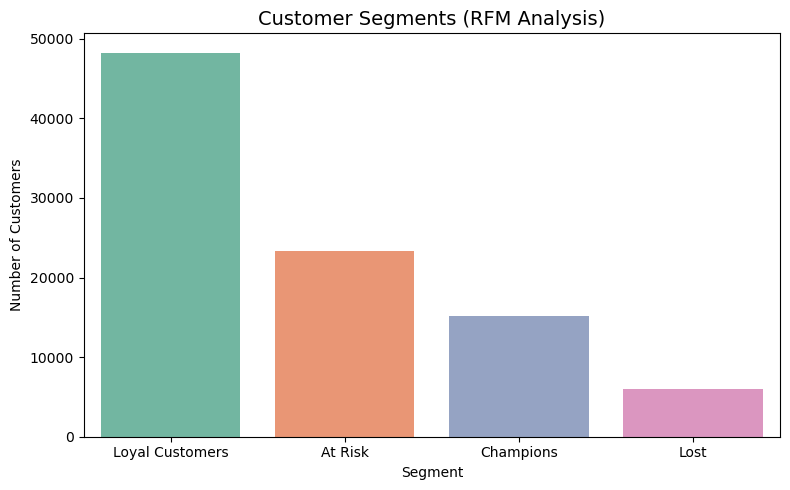

Segment
Loyal Customers    48274
At Risk            23302
Champions          15145
Lost                6025
Name: count, dtype: int64


In [33]:
snapshot_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', 
                  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, 
                          labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                          q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, 
                          labels=[1,2,3,4])

rfm['RFM_Score'] = (rfm['R_Score'].astype(int) + 
                    rfm['F_Score'].astype(int) + 
                    rfm['M_Score'].astype(int))

def segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

plt.figure(figsize=(8, 5))
seg_counts = rfm['Segment'].value_counts()
sns.barplot(x=seg_counts.index, 
            y=seg_counts.values, 
            palette='Set2')
plt.title('Customer Segments (RFM Analysis)', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('Visuals/rfm_segments.png', dpi=150)
plt.show()

print(rfm['Segment'].value_counts())

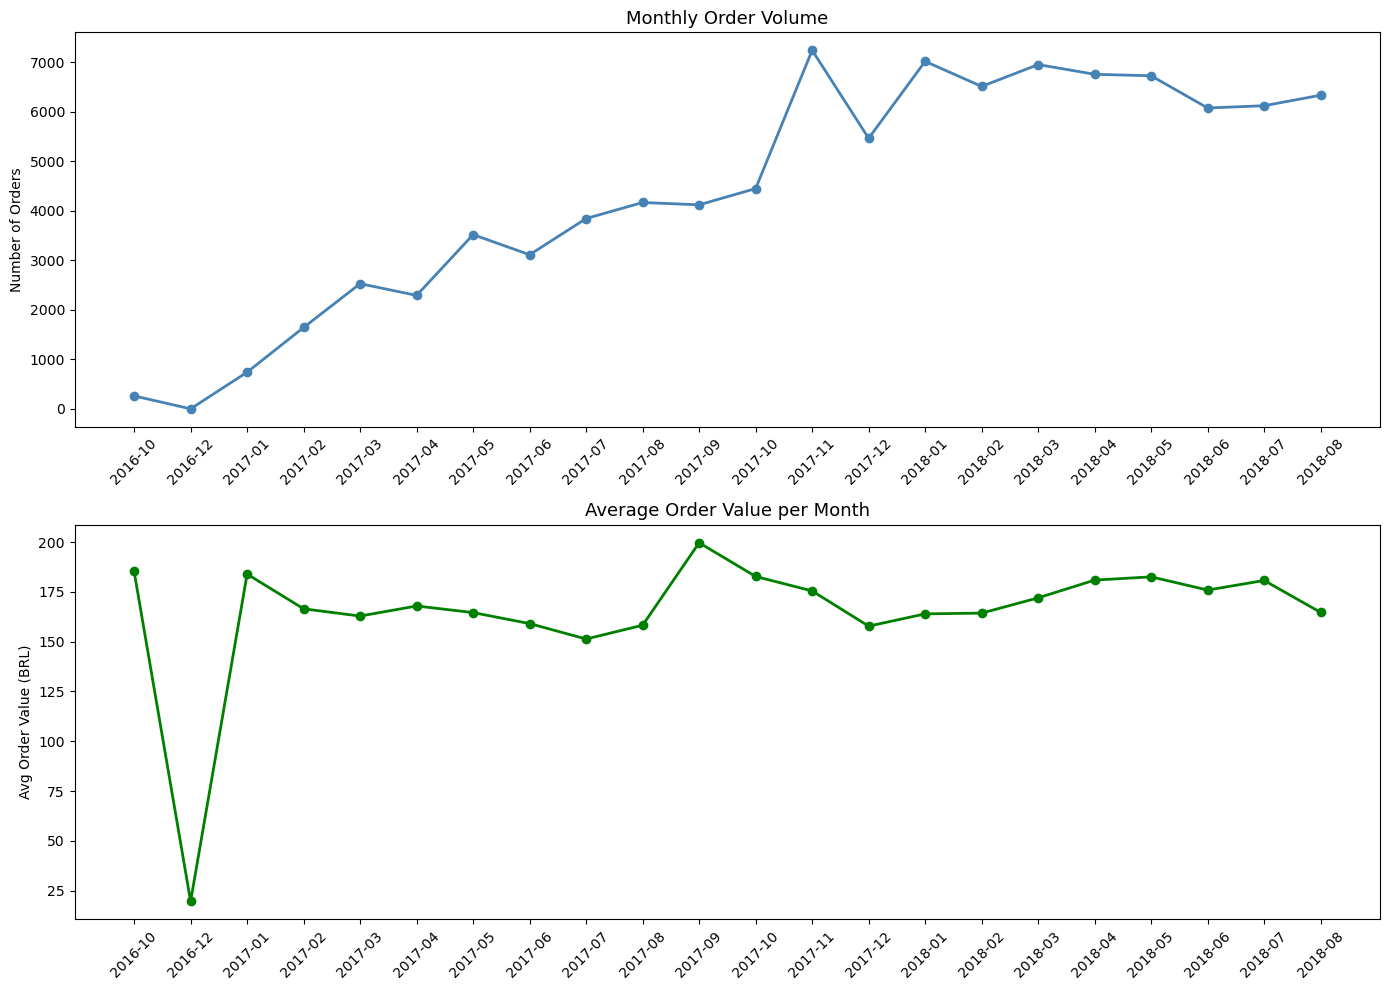

In [34]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('order_month').agg(
    Total_Orders  = ('order_id', 'nunique'),
    Total_Revenue = ('payment_value', 'sum'),
    Avg_Order_Value = ('payment_value', 'mean')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(monthly['order_month'], monthly['Total_Orders'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Monthly Order Volume', fontsize=13)
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['order_month'], monthly['Avg_Order_Value'],
             marker='o', color='green', linewidth=2)
axes[1].set_title('Average Order Value per Month', fontsize=13)
axes[1].set_ylabel('Avg Order Value (BRL)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Visuals/monthly_orders.png', dpi=150)
plt.show()

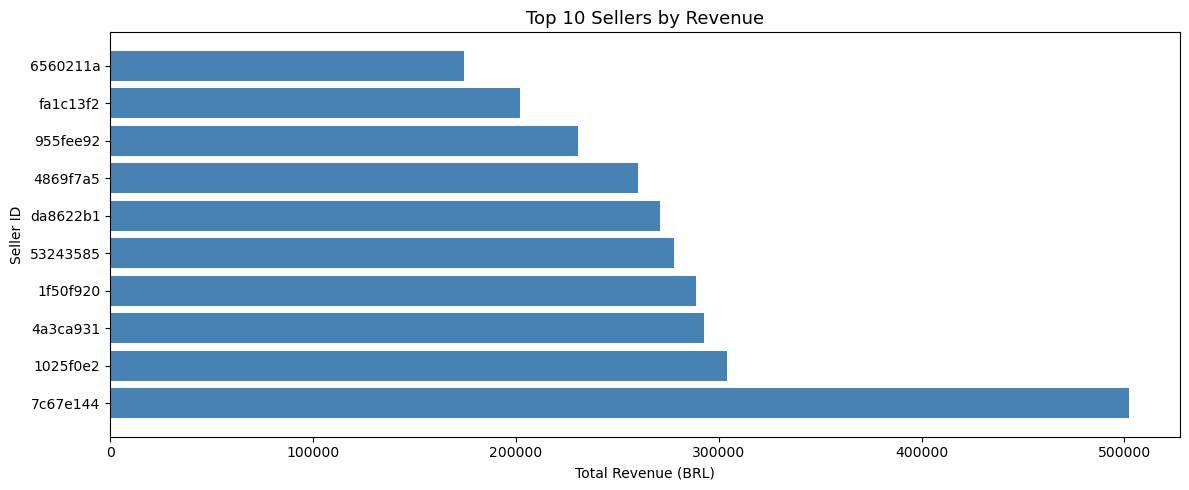

                       seller_id  Total_Revenue  Total_Orders  Avg_Rating
7c67e1448b00f6e969d365cea6b010ab      502266.10           967    3.398187
1025f0e2d44d7041d6cf58b6550e0bfa      304123.09           902    3.891123
4a3ca9315b744ce9f8e9374361493884      292703.67          1753    3.827137
1f50f920176fa81dab994f9023523100      288671.52          1394    3.991474
53243585a1d6dc2643021fd1853d8905      277690.49           346    4.120000
da8622b14eb17ae2831f4ac5b9dab84a      270822.95          1305    4.071911
4869f7a5dfa277a7dca6462dcf3b52b2      259994.39          1116    4.123077
955fee9216a65b617aa5c0531780ce60      230574.43          1253    4.090604
fa1c13f2614d7b5c4749cbc52fecda94      201922.01           574    4.376254
6560211a19b47992c3666cc44a7e94c0      174600.10          1805    3.949226


In [35]:
top_sellers = df.groupby('seller_id').agg(
    Total_Revenue = ('payment_value', 'sum'),
    Total_Orders  = ('order_id', 'nunique'),
    Avg_Rating    = ('review_score', 'mean')
).reset_index().sort_values('Total_Revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_sellers['seller_id'].str[:8], 
               top_sellers['Total_Revenue'],
               color='steelblue')
ax.set_title('Top 10 Sellers by Revenue', fontsize=13)
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Seller ID')
plt.tight_layout()
plt.savefig('Visuals/top_sellers.png', dpi=150)
plt.show()

print(top_sellers[['seller_id','Total_Revenue',
                    'Total_Orders','Avg_Rating']].to_string(index=False))

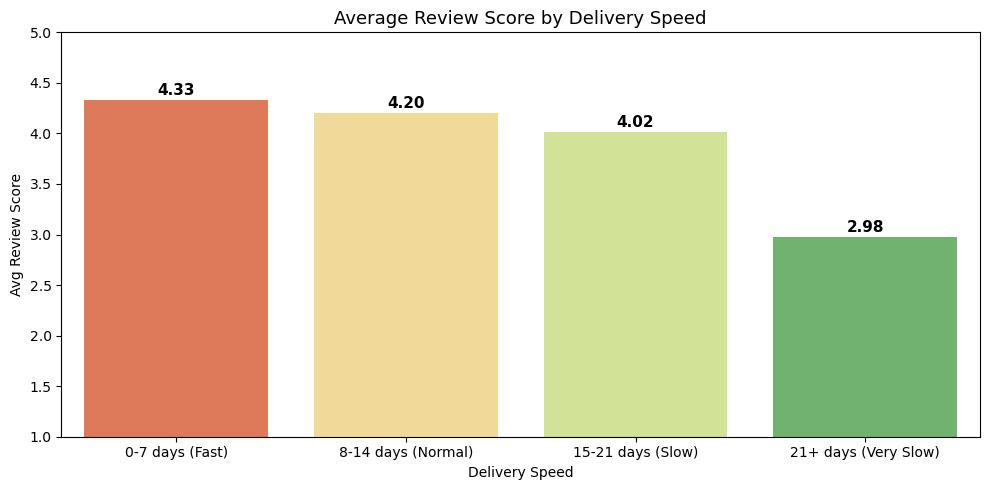

In [36]:
df_valid = df[df['delivery_days'] > 0].copy()

def delivery_bucket(days):
    if days <= 7:
        return '0-7 days (Fast)'
    elif days <= 14:
        return '8-14 days (Normal)'
    elif days <= 21:
        return '15-21 days (Slow)'
    else:
        return '21+ days (Very Slow)'

df_valid['delivery_bucket'] = df_valid['delivery_days'].apply(delivery_bucket)

bucket_order = ['0-7 days (Fast)', '8-14 days (Normal)',
                '15-21 days (Slow)', '21+ days (Very Slow)']

delivery_review = df_valid.groupby('delivery_bucket')['review_score']\
                           .mean().reindex(bucket_order).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=delivery_review,
            x='delivery_bucket',
            y='review_score',
            palette='RdYlGn')
plt.title('Average Review Score by Delivery Speed', fontsize=13)
plt.xlabel('Delivery Speed')
plt.ylabel('Avg Review Score')
plt.ylim(1, 5)
for i, row in delivery_review.iterrows():
    plt.text(i, row['review_score'] + 0.05, 
             f"{row['review_score']:.2f}", 
             ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Visuals/delivery_vs_reviews.png', dpi=150)
plt.show()


Pareto: Top 17 categories = 80% of revenue
product_category_name_english  payment_value  cumulative_pct
               bed_bath_table     1675811.59        8.566181
                health_beauty     1606596.19       16.778556
        computers_accessories     1543649.83       24.669170
                watches_gifts     1378834.91       31.717307
              furniture_decor     1378286.97       38.762642
               sports_leisure     1340662.02       45.615652
                   housewares     1064194.24       51.055452
                 garden_tools      805217.34       55.171450
                         auto      780979.54       59.163553
                   cool_stuff      736145.71       62.926480
             office_furniture      630036.31       66.147012
                         toys      597675.24       69.202125
                         baby      521838.27       71.869586
                    perfumery      494416.77       74.396877
                    telephony      467262

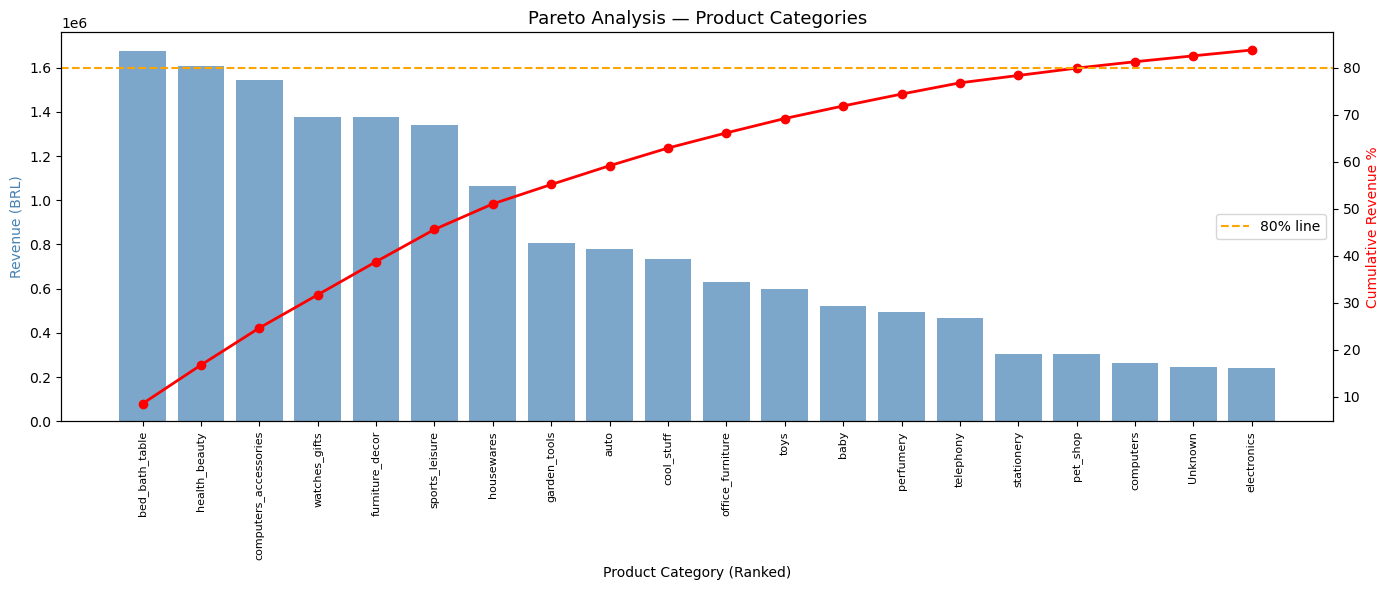

In [37]:
category_rev = df.groupby('product_category_name_english')['payment_value']\
                  .sum().sort_values(ascending=False).reset_index()

category_rev['cumulative_pct'] = (category_rev['payment_value'].cumsum() / 
                                   category_rev['payment_value'].sum() * 100)

top_80 = category_rev[category_rev['cumulative_pct'] <= 80]
print(f"\nPareto: Top {len(top_80)} categories = 80% of revenue")
print(top_80[['product_category_name_english', 
               'payment_value', 'cumulative_pct']].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(range(len(category_rev.head(20))),
        category_rev.head(20)['payment_value'],
        color='steelblue', alpha=0.7)
ax1.set_xlabel('Product Category (Ranked)')
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax1.tick_params(axis='x', rotation=90)
ax1.set_xticks(range(len(category_rev.head(20))))
ax1.set_xticklabels(category_rev.head(20)['product_category_name_english'],
                     rotation=90, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(category_rev.head(20))),
         category_rev.head(20)['cumulative_pct'],
         color='red', marker='o', linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', label='80% line')
ax2.set_ylabel('Cumulative Revenue %', color='red')
ax2.legend(loc='center right')

plt.title('Pareto Analysis — Product Categories', fontsize=13)
plt.tight_layout()
plt.savefig('Visuals/pareto_analysis.png', dpi=150)
plt.show()

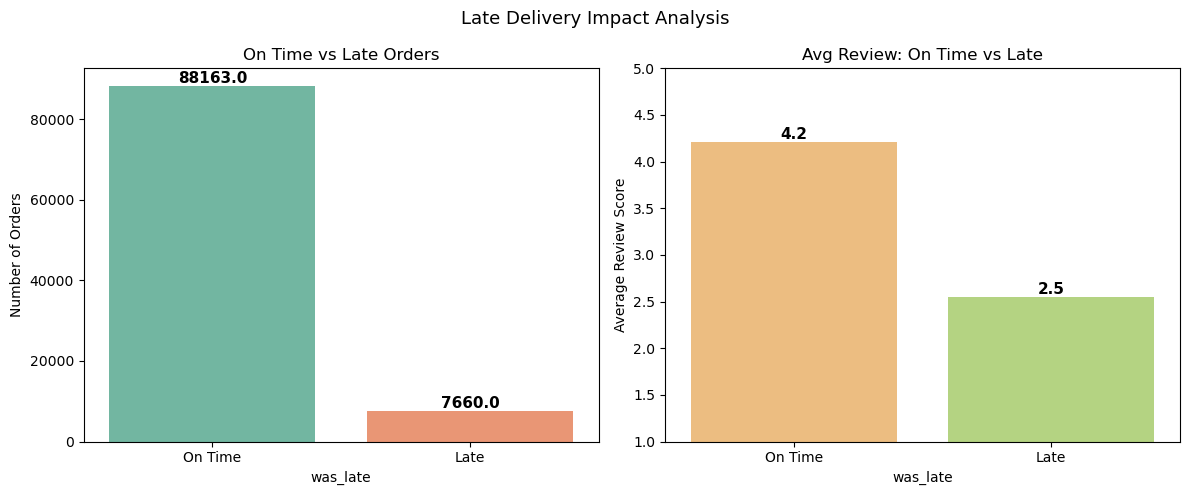


Late Delivery Summary:
was_late  Orders  Avg_Review  Total_Revenue
 On Time   88163    4.210569    17997724.54
    Late    7660    2.545929     1565388.33


In [38]:
df['was_late'] = (df['order_delivered_customer_date'] > 
                  df['order_estimated_delivery_date'])

late_summary = df.groupby('was_late').agg(
    Orders        = ('order_id', 'nunique'),
    Avg_Review    = ('review_score', 'mean'),
    Total_Revenue = ('payment_value', 'sum')
).reset_index()

late_summary['was_late'] = late_summary['was_late'].map(
    {False: 'On Time', True: 'Late'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=late_summary, x='was_late', 
            y='Orders', palette='Set2', ax=axes[0])
axes[0].set_title('On Time vs Late Orders', fontsize=12)
axes[0].set_ylabel('Number of Orders')

sns.barplot(data=late_summary, x='was_late',
            y='Avg_Review', palette='RdYlGn', ax=axes[1])
axes[1].set_title('Avg Review: On Time vs Late', fontsize=12)
axes[1].set_ylabel('Average Review Score')
axes[1].set_ylim(1, 5)

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Late Delivery Impact Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('Visuals/late_delivery_impact.png', dpi=150)
plt.show()

print("\nLate Delivery Summary:")
print(late_summary.to_string(index=False))